{'topic': '猫咪', 'poem': '**《咏猫》**\n\n狸奴昼卧暖窗纱，\n梦逐飞蝶入野家。\n忽听瓶倾惊起坐，\n回眸一笑弄梅花。\n\n**赏析：**\n这首诗描绘了一只猫咪慵懒而灵动的日常。前两句写它在阳光下于窗纱旁酣睡，梦中似乎还在追逐蝴蝶；后两句笔锋一转，写它被瓶子倒下的声音惊醒，起身时爪子沾了墨或泥，在地上踩出如梅花般的脚印，既生动又充满趣味。', 'ci_poem': '这是一首以**《清平乐》**为词牌填写的关于猫咪的词。这首词试图捕捉猫咪慵懒、傲娇又可爱的神态，以及它与主人之间微妙而温馨的互动。\n\n### **《清平乐·狸奴午梦》**\n\n**绒球初醒，**\n**斜倚窗纱静。**\n**金线穿庭花影正，**\n**独对春风弄晴。**\n\n**轻跳案头书侧，**\n**墨香偷染毛色。**\n**忽见蝶飞墙隙，**\n**尾尖微颤如戟。**\n\n---\n\n### **【注释与赏析】**\n\n*   **上片（写静）：**\n    *   **“绒球初醒，斜倚窗纱静”**：描绘猫咪刚睡醒时，像一团柔软的绒球，慵懒地靠在窗纱边，享受着午后的宁静。\n    *   **“金线穿庭花影正，独对春风弄晴”**：阳光如金线般穿过庭院，花影斑驳。猫咪独自对着春风，似乎在把玩着晴好的天气，尽显其悠闲自在。\n\n*   **下片（写动）：**\n    *   **“轻跳案头书侧，墨香偷染毛色”**：猫咪轻轻跳上书桌，趴在主人的书旁。这里用“偷染”拟人化，仿佛它沾染了书香，也暗示了它偶尔会捣乱踩到墨迹或书本的小调皮。\n    *   **“忽见蝶飞墙隙，尾尖微颤如戟”**：忽然看见蝴蝶飞过墙缝，原本慵懒的它瞬间警觉，尾巴尖端微微颤抖，像竖起的短戟一样蓄势待发，生动刻画了猫咪捕猎本能被激发时的可爱瞬间。', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '有一天，一只猫去面试工作。\n\n面试官问它：“你有什么特长吗？”\n\n猫自信地回答：“我会‘喵’。”\n\n面试官摇摇头说：“这不算特长，这是本能。你会什么别的吗？”\n\n猫想了想，说：“那我还会……**把桌子上的水杯推下去**。”\n\n面试官叹了口气：“这也是本能！你就没有一项是通过后天努力学习掌握的技能吗？”\n\n猫沉思

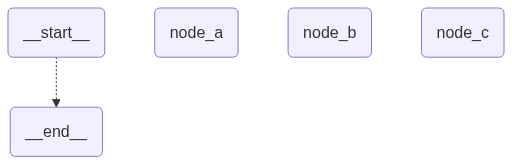

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal,Sequence

load_dotenv()

# 初始化模型
model = init_chat_model(
    "qwen3.7-plus-2026-05-26",
    model_provider="openai",
    temperature=0.5,
    max_tokens=1024,
    timeout=60,
    max_retries=3,
    base_url=os.getenv("DASHSCOPE_API_URL"),
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    extra_body={
        "thinking": {
            "type": "disabled"
            }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str
    content_type: str

def node_a(state: OverAllState) -> OverAllState:
    '''
    生成七言绝句
    '''
    poem = model.invoke([HumanMessage(content=f"写一首关于{state['topic']}主题的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    '''
    生成笑话
    '''
    joke = model.invoke([HumanMessage(content=f"写一个关于{state['topic']}主题的笑话")]).content

    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    '''
    生成词
    '''
    ci_poem = model.invoke([HumanMessage(content=f"写一首关于{state['topic']}主题的词")]).content

    return {
        "ci_poem": ci_poem
    }

def my_route(state: OverAllState) -> Sequence[Literal["node_a","node_b","node_c"]]:
    '''
    路由
    '''
    if "诗" in state["content_type"]:
        return ["node_a","node_c"]
    else:
        return ["node_b","node_c"]

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_conditional_edges(START, my_route)

builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
result = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(result)

result = graph.invoke({"topic": "猫咪", "content_type": "笑话"})
print(result)

from IPython.display import display
display(graph)